In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from sklearn.preprocessing import MinMaxScaler
import math as ma
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import numpy as np

In [2]:
connect = sqlite3.connect("C:/Forge/Python/database.db")
df = pd.read_sql('SELECT * FROM weather5', connect)
connect.close()

In [3]:
def get_label_list(df, flag_print):
    label_list = df.columns.tolist() 
    for i in range(len(label_list)):
        df[label_list[i]] = pd.to_numeric(df[label_list[i]], errors='coerce') # заменяем пропуски на NaN
        if (flag_print):
            print(i, "/", i - len(label_list), ": ", label_list[i], sep="", end="  ")
    return label_list

label_list = get_label_list(df, 1)
    
mode = 1

if mode == 1:
    for i in range(len(label_list)):
        df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)
    df = df.dropna()
elif mode == 2:
    # Создаём словарь средних значений
    fill_values = {col: df[col].mean() for col in label_list}

    # Заполняем пропуски во всех столбцах за один вызов
    df.fillna(fill_values, inplace=True)

df.head(-1)

0/-9: id  1/-8: year  2/-7: month  3/-6: day  4/-5: max_temp  5/-4: sr_temp  6/-3: min_temp  7/-2: precipit  8/-1: norm_plus  

,id,year,month,day,max_temp,sr_temp,min_temp,precipit,norm_plus
0,1,1881,1,1,1.0,-0.2,-1.5,1.3,6.5
1,2,1881,1,2,1.7,-1.1,-2.5,0.1,5.8
2,3,1881,1,3,1.9,1.1,-0.9,0.0,8.1
3,4,1881,1,4,2.2,1.7,0.7,0.4,8.8
4,5,1881,1,5,2.2,-6.1,-10.4,0.0,1.1
...,...,...,...,...,...,...,...,...,...
53297,53298,2026,8,15,18.8,16.1,13.5,5.0,-1.6
53298,53299,2026,8,16,22.3,18.1,14.7,1.0,0.6
53299,53300,2026,8,17,19.5,17.1,15.1,0.4,-0.3
53300,53301,2026,8,18,20.0,16.8,14.6,6.5,-0.5


In [4]:
df['year'] = df['year'].shift(-1)                               #
df['month'] = df['month'].shift(-1)                             # Перемещение календарных параметров завтра в сегодняшним параметрам погоды
df['day'] = df['day'].shift(-1)                                 #

step = 3
df['sr_temp'] = df['sr_temp'].shift(-1)
for i in range(1, step+1):
    df[f'sr_temp_to_temp_{i}'] = df['sr_temp'].shift(i) - df['sr_temp'].shift(i+1) 
   
# df['sr_temp_month'] = df['sr_temp'].rolling(window=30, min_periods=30).mean().shift(1)
# df['sr_temp_20days'] = df['sr_temp'].rolling(window=20, min_periods=20).mean().shift(1)
df['sr_temp_seson'] = df['sr_temp'].rolling(window=70, min_periods=70).mean().shift(1)

df['ras_temp'] = df['max_temp'] - df['min_temp']      # Получения разброса температур

df = df.dropna()

day = df['day'].tail(1).item()          # параметры для последующего счётчика
month = df['month'].tail(1).item()      #

label_list = get_label_list(df, 0)

days_in_month_1 = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] # количество дней в каждом месяце не весокостного года
days_in_month_2 = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] # количество дней в каждом месяце весокостного года

def day_of_year(x):                                                                 # 
    try:                                                                            #
        if x['year'] % 400 == 0 or x['year'] % 4 == 0 and x['year'] % 100 != 0:     #                               # 
            return sum(days_in_month_2[:int(x['month'])-1]) + int(x['day'])         # функция возвращающая номер дня в году
        else:                                                                       #
            return sum(days_in_month_1[:int(x['month'])-1]) + int(x['day'])         #
    except:                                                                         #
        pass                                                                        #

def day_degree(x):
    if x['year'] % 400 == 0 or x['year'] % 4 == 0 and x['year'] % 100 != 0: 
        day_m = days_in_month_2       
    else:                                                                        
        day_m = days_in_month_1
    return (x['day'] - 1) / (day_m[int(x['month'])-1] - 1)

df['day_of_year'] = df[['year', 'month', 'day']].apply(day_of_year, axis=1)

scal = MinMaxScaler()
df['month_degree'] = scal.fit_transform(df[['month']]) * 2 * ma.pi   # преобразуем номер месяца в соответствующее количество радиан, где 12-ый месяц = 6.28 радиан
df['day_degree'] = df[['day', 'year', 'month']].apply(day_degree, axis=1) * 2 * ma.pi        # преобразуем номер дня в месяце в соответствующее количество радиан, где последний день месяца = 6.28 радиан
df['day_of_year'] = scal.fit_transform(df[['day_of_year']]) * 2 * ma.pi    # преобразуем номер дня в году в соответствующее количество радиан, где 365 день = 6.28 радиан
def set_rad_cos(x):
    return ma.cos(x)
def set_rad_sin(x):
    return ma.sin(x)

df['month_cos'] = df['month_degree'].apply(set_rad_cos)
df['month_sin'] = df['month_degree'].apply(set_rad_sin)

df['day_cos'] = df['day'].apply(set_rad_cos)
df['day_sin'] = df['day'].apply(set_rad_sin)

df['day_of_year_cos'] = df['day_of_year'].apply(set_rad_cos)
df['day_of_year_sin'] = df['day_of_year'].apply(set_rad_sin)


df = df.drop(['id', 'day_of_year', 'max_temp', 'min_temp', 'norm_plus', 'precipit', 'ras_temp', 'month_degree', 'day_degree'], axis=1)         # убираем все ненужные колонки датасета

label_list = get_label_list(df, 1)
print()
df.head(-1)

0/-14: year  1/-13: month  2/-12: day  3/-11: sr_temp  4/-10: sr_temp_to_temp_1  5/-9: sr_temp_to_temp_2  6/-8: sr_temp_to_temp_3  7/-7: sr_temp_seson  8/-6: month_cos  9/-5: month_sin  10/-4: day_cos  11/-3: day_sin  12/-2: day_of_year_cos  13/-1: day_of_year_sin  


,year,month,day,sr_temp,sr_temp_to_temp_1,sr_temp_to_temp_2,sr_temp_to_temp_3,sr_temp_seson,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin
71,1881.0,3.0,13.0,-6.3,-0.3,-0.6,-3.2,-10.184286,0.415415,0.909632,0.907447,0.420167,0.341571,0.939856
72,1881.0,3.0,14.0,-9.0,-1.5,-0.3,-0.6,-10.258571,0.415415,0.909632,0.136737,0.990607,0.325342,0.945596
73,1881.0,3.0,15.0,-13.6,-2.7,-1.5,-0.3,-10.402857,0.415415,0.909632,-0.759688,0.650288,0.309017,0.951057
74,1881.0,3.0,16.0,-7.0,-4.6,-2.7,-1.5,-10.621429,0.415415,0.909632,-0.957659,-0.287903,0.292600,0.956235
75,1881.0,3.0,17.0,-4.4,6.6,-4.6,-2.7,-10.634286,0.415415,0.909632,-0.275163,-0.961397,0.276097,0.961130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53296,2026.0,8.0,15.0,16.1,0.3,-0.5,-2.4,18.588571,-0.654861,-0.755750,-0.759688,0.650288,-0.732494,-0.680773
53297,2026.0,8.0,16.0,18.1,0.8,0.3,-0.5,18.485714,-0.654861,-0.755750,-0.957659,-0.287903,-0.720667,-0.693281
53298,2026.0,8.0,17.0,17.1,2.0,0.8,0.3,18.487143,-0.654861,-0.755750,-0.275163,-0.961397,-0.708627,-0.705584
53299,2026.0,8.0,18.0,16.8,-1.0,2.0,0.8,18.454286,-0.654861,-0.755750,0.660317,-0.750987,-0.696376,-0.717677


In [5]:
x = pd.DataFrame(df.copy().iloc[:, [i for i in range(len(label_list)) if (i not in [3])]])
y = pd.DataFrame(df.copy().iloc[:, [1]])

53121
Набор данных делится на 3
Выбран отрезок от 0 до 17707


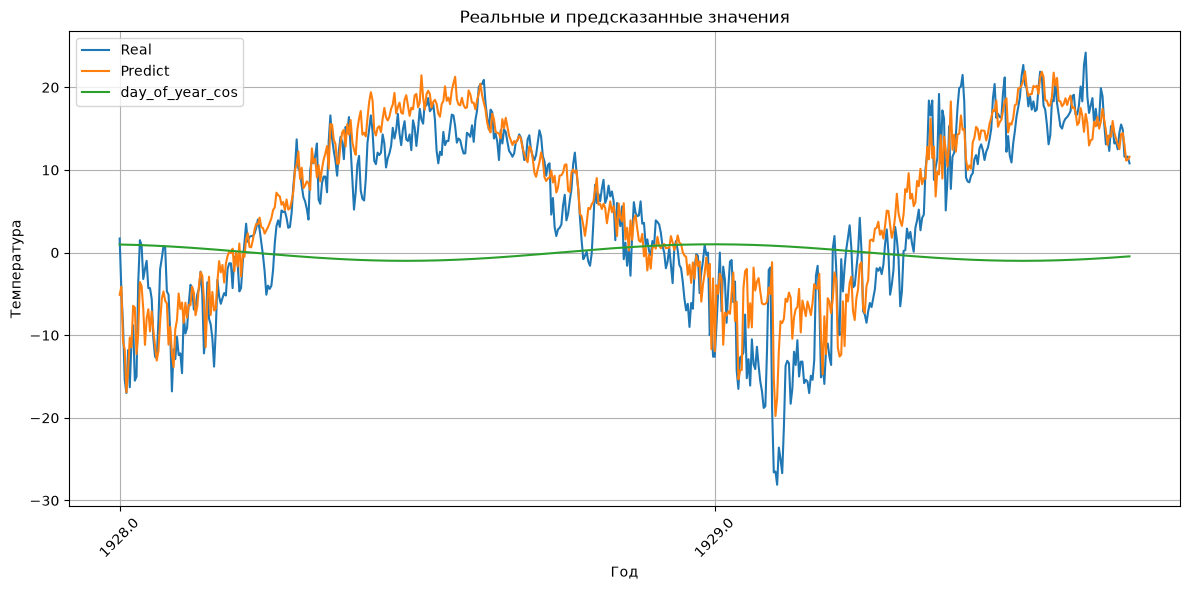

coef:
       year     month       day  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.009149  0.057408  0.003241           0.032435           0.016312   

   sr_temp_to_temp_3  sr_temp_seson  month_cos  month_sin   day_cos   day_sin  \
0           0.014396       0.119443   0.007044   0.004354  0.002354  0.002676   

   day_of_year_cos  day_of_year_sin  
0         0.653826         0.077362  
------------------------
# MAE и MSE по обучающей выборке
Train MSE:  9.824054718017578
Train MAE:  2.429558277130127
------------------------
# MAE и MSE по тестовой выборке
Test MSE:  18.212186813354492
Test MAE:  3.3297324180603027
------------------------
R^2: 0.8263782262802124


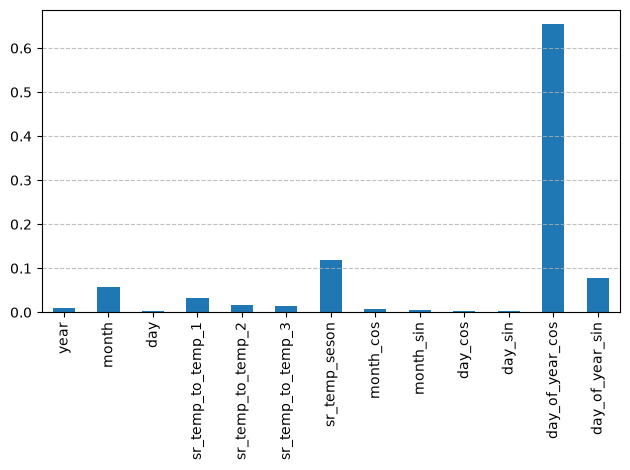

Выбран отрезок от 17707 до 35414


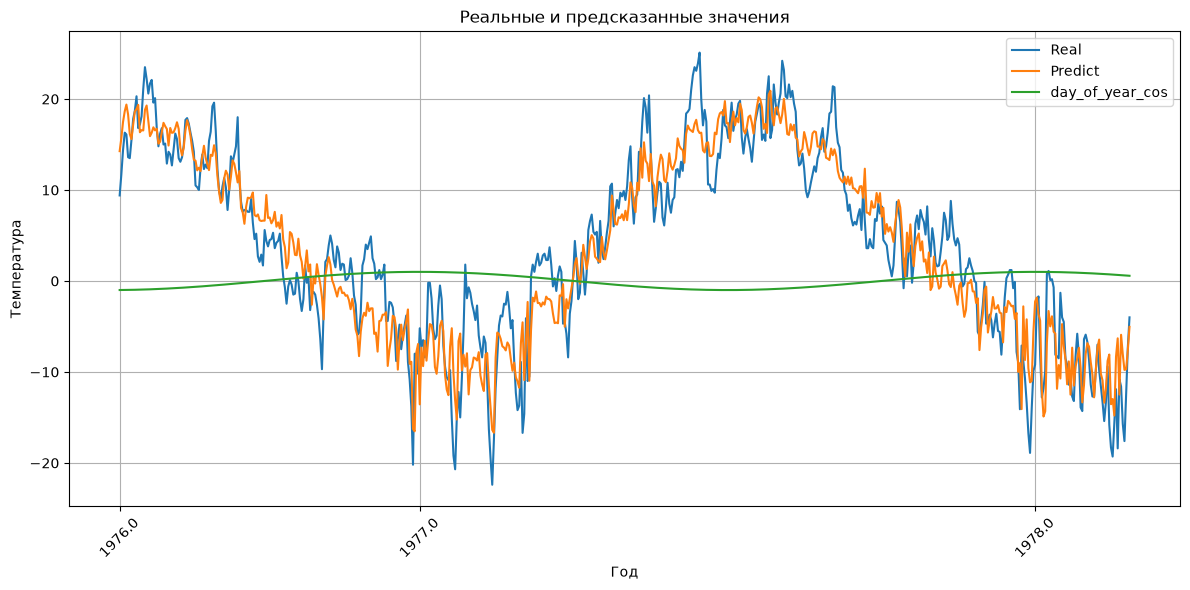

coef:
       year     month       day  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.008992  0.049576  0.003624           0.031854           0.014767   

   sr_temp_to_temp_3  sr_temp_seson  month_cos  month_sin   day_cos   day_sin  \
0           0.012742       0.122934   0.005564   0.005713  0.002682  0.003129   

   day_of_year_cos  day_of_year_sin  
0         0.674346         0.064077  
------------------------
# MAE и MSE по обучающей выборке
Train MSE:  10.246944427490234
Train MAE:  2.4878790378570557
------------------------
# MAE и MSE по тестовой выборке
Test MSE:  14.74984359741211
Test MAE:  2.9867055416107178
------------------------
R^2: 0.8588480949401855


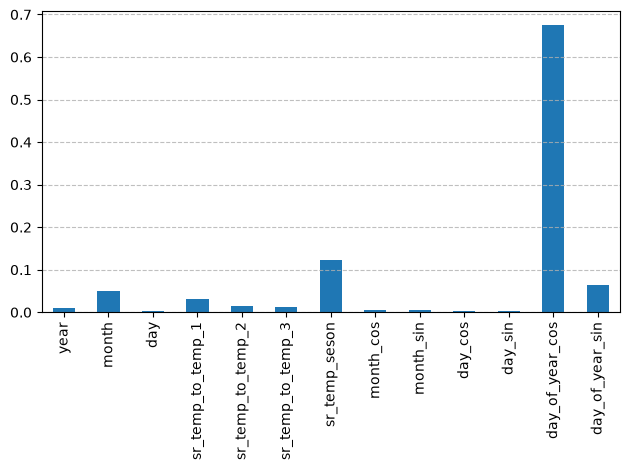

Выбран отрезок от 35414 до 53121


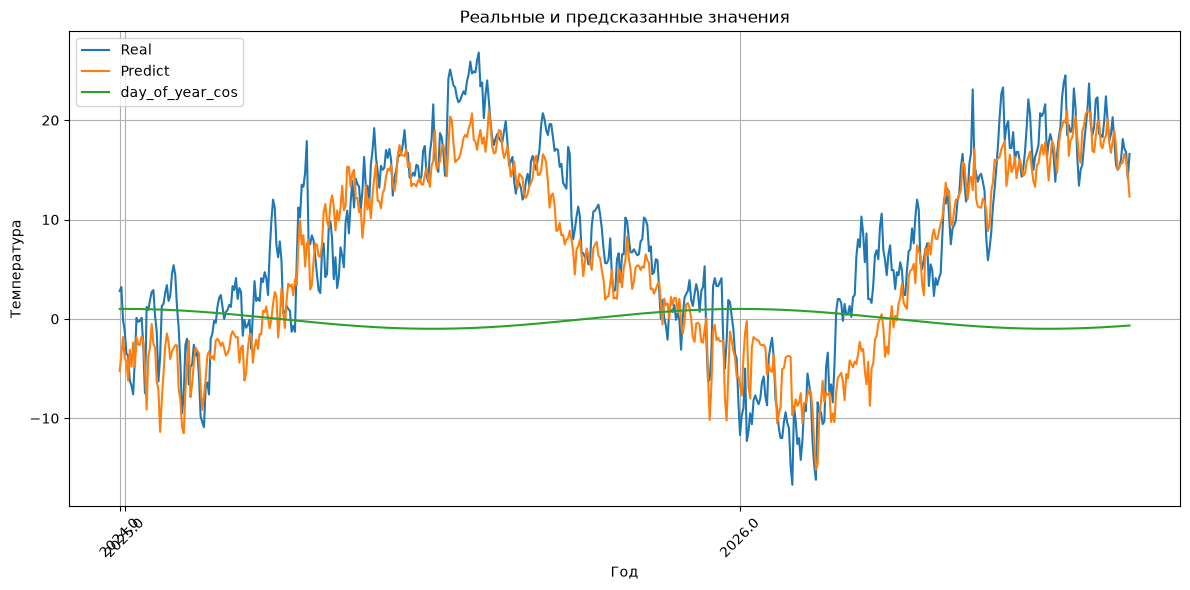

coef:
       year     month       day  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.005921  0.038599  0.004514           0.032269           0.015672   

   sr_temp_to_temp_3  sr_temp_seson  month_cos  month_sin   day_cos   day_sin  \
0            0.01323       0.112242   0.016667   0.004805  0.002805  0.002942   

   day_of_year_cos  day_of_year_sin  
0         0.667198         0.083136  
------------------------
# MAE и MSE по обучающей выборке
Train MSE:  10.202335357666016
Train MAE:  2.4857397079467773
------------------------
# MAE и MSE по тестовой выборке
Test MSE:  18.216838836669922
Test MAE:  3.3763201236724854
------------------------
R^2: 0.8076350688934326


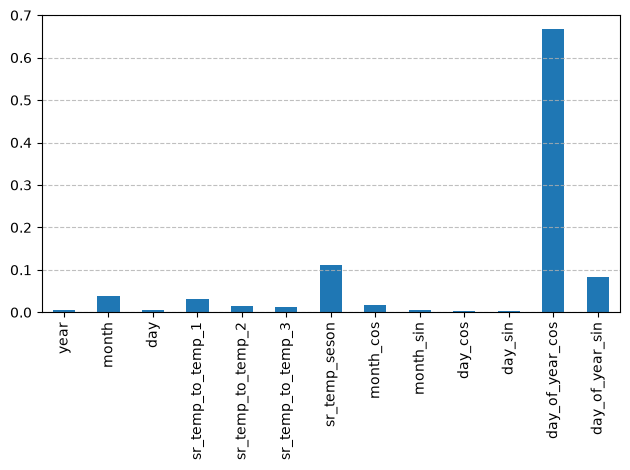

,Predicted
71,-4.370734
72,-3.171446
73,-5.199931
74,-8.441274
75,-3.924895
...,...
53296,15.604449
53297,15.745855
53298,16.626816
53299,15.989730


In [6]:
print(len(df))
drop_numer = 2
for i in range(3, 20):
    if len(df) % i == 0:
        drop_numer = i
        break

df_predict = pd.DataFrame({'Predicted': np.nan}, index=df.index)
naget = len(df) // drop_numer
print('Набор данных делится на', drop_numer)
for i in range(drop_numer):
    df_naget = df.iloc[i*(naget): (i+1)*(naget)]
    df_unnaget = df.drop(df_naget.index)
    print(f'Выбран отрезок от {i*(naget)} до {(i+1)*(naget)}')

    label_list = get_label_list(df_naget, 0)

    label_number_list = [i for i in range(len(label_list)) if (i not in [3])]

    x_train, x_test = df_unnaget.iloc[:, label_number_list], df_naget.iloc[:,label_number_list]
    y_train, y_test = df_unnaget.iloc[:, [3]], df_naget.iloc[:, [3]]

    model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5)
    model.fit(x_train, y_train)

    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    df_predict.loc[df_naget.index, 'Predicted'] = y_pred_test

    deep = 600

    label_list = pd.DataFrame(x_test).columns.tolist()

    m = model.feature_importances_
    maxm = 0
    name_max = 0
    cof = pd.DataFrame()
    for i in range(len(label_list)):
        cof[label_list[i]] = [m[i]]
        if m[i] > maxm:
            maxm = m[i]
            name_max = label_list[i]


    real_vals = y_test['sr_temp'].values[-deep:]
    pred_vals = y_pred_test[-deep:]

    x_indexes = range(len(real_vals))

    plt.figure(figsize=(12, 6))
    plt.plot(x_indexes, real_vals, label='Real')
    plt.plot(x_indexes, pred_vals, label='Predict')
    plt.plot(x_indexes, df_naget[name_max][-deep:], label=name_max)
    df_tail = df_naget.iloc[-deep:]

    years = df_tail['year'].values
    change_points = [0]
    for i in range(1, len(years)):
        if years[i] != years[i-1]:
            change_points.append(i)

    tick_positions = change_points
    tick_labels = [str(years[pos]) for pos in change_points]

    plt.xticks(tick_positions, tick_labels, rotation=45)

    plt.xlabel('Год')
    plt.ylabel('Температура')
    plt.title('Реальные и предсказанные значения')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    print('coef:')
    print(cof)
    df_tail = df_naget.dropna()

    print("------------------------")
    print("# MAE и MSE по обучающей выборке")
    print("Train MSE: ", mean_squared_error(y_train, y_pred_train))
    print("Train MAE: ", mean_absolute_error(y_train, y_pred_train))

    print("------------------------")
    print("# MAE и MSE по тестовой выборке")
    print("Test MSE: ", mean_squared_error(y_test, y_pred_test))
    print("Test MAE: ", mean_absolute_error(y_test, y_pred_test))

    print("------------------------")
    r = r2_score(y_test, y_pred_test)
    p = len(label_list)
    print("R^2:", r)

    coef_col_par = pd.DataFrame({
        "Параметр": [label_list],
        "коэффициент": [model.feature_importances_]})

    cof.iloc[0].plot(kind='bar')
    plt.grid(axis='y', linestyle='--', alpha=0.8)
    plt.tight_layout()
    plt.show()

df_predict.head(-1)

In [7]:
df['Predicted'] = df_predict['Predicted'] - df['sr_temp'].shift(1)

label_list = get_label_list(df, 1)

x = pd.DataFrame(df.copy().iloc[:, [i for i in range(len(label_list)) if (i not in [3])]])
y = pd.DataFrame(df.copy().iloc[:, [3]])

train_size = int(len(x) * 0.8)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

model = RandomForestRegressor(max_depth=10, max_features=5)
model.fit(x_train,y_train)

y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

df['Real'] = df['sr_temp']
y_pred_df = pd.DataFrame({'Predicted3': y_pred_test}, index=y_test.index)
df = df.join(y_pred_df, how='left')
df.head(-1)


0/-15: year  1/-14: month  2/-13: day  3/-12: sr_temp  4/-11: sr_temp_to_temp_1  5/-10: sr_temp_to_temp_2  6/-9: sr_temp_to_temp_3  7/-8: sr_temp_seson  8/-7: month_cos  9/-6: month_sin  10/-5: day_cos  11/-4: day_sin  12/-3: day_of_year_cos  13/-2: day_of_year_sin  14/-1: Predicted  

c:\Users\ivanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,year,month,day,sr_temp,sr_temp_to_temp_1,sr_temp_to_temp_2,sr_temp_to_temp_3,sr_temp_seson,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin,Predicted,Real,Predicted3
71,1881.0,3.0,13.0,-6.3,-0.3,-0.6,-3.2,-10.184286,0.415415,0.909632,0.907447,0.420167,0.341571,0.939856,NaN,-6.3,NaN
72,1881.0,3.0,14.0,-9.0,-1.5,-0.3,-0.6,-10.258571,0.415415,0.909632,0.136737,0.990607,0.325342,0.945596,3.128554,-9.0,NaN
73,1881.0,3.0,15.0,-13.6,-2.7,-1.5,-0.3,-10.402857,0.415415,0.909632,-0.759688,0.650288,0.309017,0.951057,3.800069,-13.6,NaN
74,1881.0,3.0,16.0,-7.0,-4.6,-2.7,-1.5,-10.621429,0.415415,0.909632,-0.957659,-0.287903,0.292600,0.956235,5.158726,-7.0,NaN
75,1881.0,3.0,17.0,-4.4,6.6,-4.6,-2.7,-10.634286,0.415415,0.909632,-0.275163,-0.961397,0.276097,0.961130,3.075105,-4.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53296,2026.0,8.0,15.0,16.1,0.3,-0.5,-2.4,18.588571,-0.654861,-0.755750,-0.759688,0.650288,-0.732494,-0.680773,0.304449,16.1,15.550358
53297,2026.0,8.0,16.0,18.1,0.8,0.3,-0.5,18.485714,-0.654861,-0.755750,-0.957659,-0.287903,-0.720667,-0.693281,-0.354145,18.1,17.523096
53298,2026.0,8.0,17.0,17.1,2.0,0.8,0.3,18.487143,-0.654861,-0.755750,-0.275163,-0.961397,-0.708627,-0.705584,-1.473184,17.1,18.207081
53299,2026.0,8.0,18.0,16.8,-1.0,2.0,0.8,18.454286,-0.654861,-0.755750,0.660317,-0.750987,-0.696376,-0.717677,-1.110270,16.8,16.703365


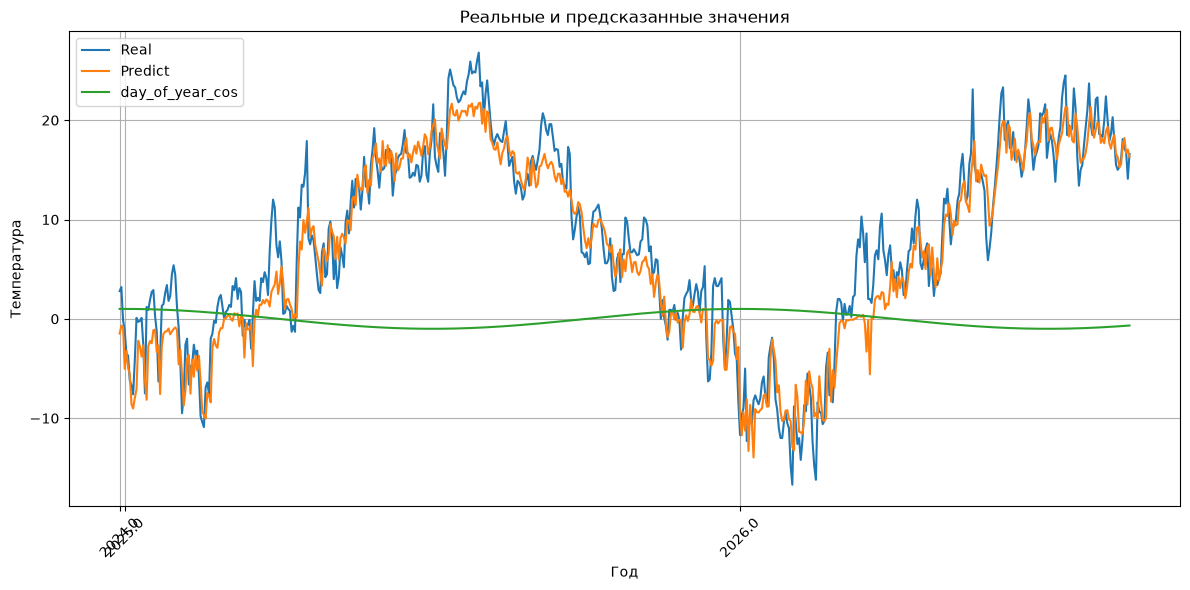

coef:
       year     month       day  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.003302  0.099642  0.002888           0.026452           0.006369   

   sr_temp_to_temp_3  sr_temp_seson  month_cos  month_sin   day_cos   day_sin  \
0            0.00449       0.149343   0.210742   0.032438  0.000615  0.000665   

   day_of_year_cos  day_of_year_sin  Predicted  
0         0.327536         0.056798    0.07872  
------------------------
# MAE и MSE по обучающей выборке
Train MSE:  6.971692266241062
Train MAE:  2.0251883599041274
------------------------
# MAE и MSE по тестовой выборке
Test MSE:  7.951904983600862
Test MAE:  2.1897950661912966
------------------------
R^2: 0.9157612786854423


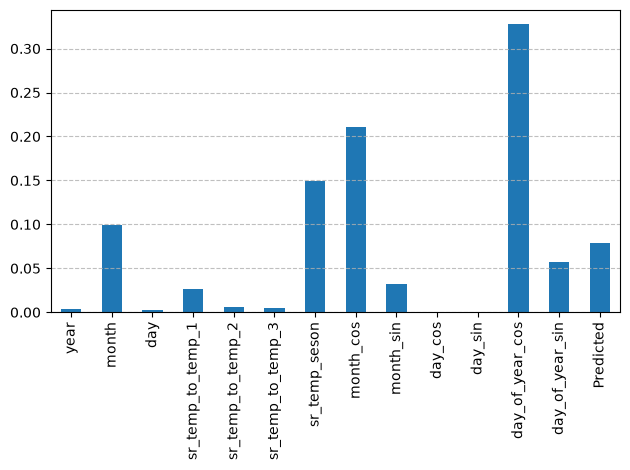

In [8]:
deep = 600

label_list = pd.DataFrame(x_test).columns.tolist()

m = model.feature_importances_
maxm = 0
name_max = 0
cof = pd.DataFrame()
for i in range(len(label_list)):
    cof[label_list[i]] = [m[i]]
    if m[i] > maxm:
        maxm = m[i]
        name_max = label_list[i]


real_vals = y_test['sr_temp'].values[-deep:]
pred_vals = y_pred_test[-deep:]

x_indexes = range(len(real_vals))

plt.figure(figsize=(12, 6))
plt.plot(x_indexes, real_vals, label='Real')
plt.plot(x_indexes, pred_vals, label='Predict')
plt.plot(x_indexes, df[name_max][-deep:], label=name_max)
df_tail = df.iloc[-deep:]

years = df_tail['year'].values
change_points = [0]
for i in range(1, len(years)):
    if years[i] != years[i-1]:
        change_points.append(i)

tick_positions = change_points
tick_labels = [str(years[pos]) for pos in change_points]

plt.xticks(tick_positions, tick_labels, rotation=45)

plt.xlabel('Год')
plt.ylabel('Температура')
plt.title('Реальные и предсказанные значения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


print('coef:')
print(cof)
df_tail = df_naget.dropna()

print("------------------------")
print("# MAE и MSE по обучающей выборке")
print("Train MSE: ", mean_squared_error(y_train, y_pred_train))
print("Train MAE: ", mean_absolute_error(y_train, y_pred_train))

print("------------------------")
print("# MAE и MSE по тестовой выборке")
print("Test MSE: ", mean_squared_error(y_test, y_pred_test))
print("Test MAE: ", mean_absolute_error(y_test, y_pred_test))

print("------------------------")
r = r2_score(y_test, y_pred_test)
p = len(label_list)
print("R^2:", r)

coef_col_par = pd.DataFrame({
    "Параметр": [label_list],
    "коэффициент": [model.feature_importances_]})

cof.iloc[0].plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

In [9]:
df = df.drop(['Real'], axis=1)
get_label_list(df, 1)
df.head(1)

0/-16: year  1/-15: month  2/-14: day  3/-13: sr_temp  4/-12: sr_temp_to_temp_1  5/-11: sr_temp_to_temp_2  6/-10: sr_temp_to_temp_3  7/-9: sr_temp_seson  8/-8: month_cos  9/-7: month_sin  10/-6: day_cos  11/-5: day_sin  12/-4: day_of_year_cos  13/-3: day_of_year_sin  14/-2: Predicted  15/-1: Predicted3  

,year,month,day,sr_temp,sr_temp_to_temp_1,sr_temp_to_temp_2,sr_temp_to_temp_3,sr_temp_seson,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin,Predicted,Predicted3
71,1881.0,3.0,13.0,-6.3,-0.3,-0.6,-3.2,-10.184286,0.415415,0.909632,0.907447,0.420167,0.341571,0.939856,NaN,NaN


XBoost:
       year     month       day  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.006898  0.043376  0.002814            0.03199           0.015128   

   sr_temp_to_temp_3  sr_temp_seson  month_cos  month_sin   day_cos   day_sin  \
0            0.01267       0.127216   0.003226   0.003268  0.002172  0.002121   

   day_of_year_cos  day_of_year_sin  
0         0.681633         0.067488  
------------------------


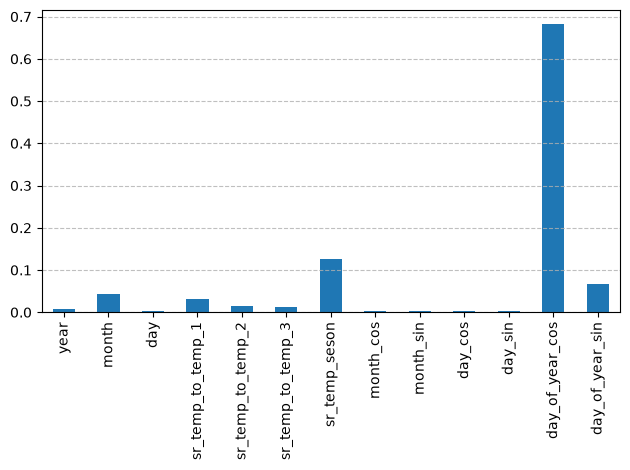

c:\Users\ivanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RForest:
       year     month       day  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.011938  0.072843  0.006472           0.034751           0.013906   

   sr_temp_to_temp_3  sr_temp_seson  month_cos  month_sin   day_cos   day_sin  \
0           0.012416       0.152975   0.158664    0.04085  0.004529  0.004647   

   day_of_year_cos  day_of_year_sin  Predicted  
0         0.348531         0.049338   0.088141  
------------------------


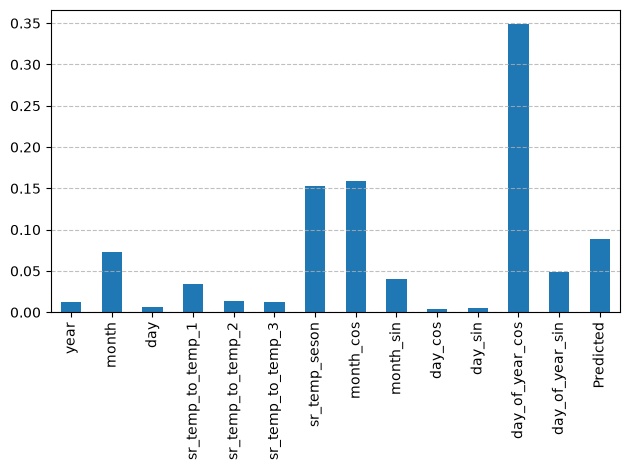

In [10]:
label_list = pd.DataFrame(df).columns.tolist()

label_number_list = [i for i in range(len(label_list)) if (i not in [3, 14, 15])]

x_train = df.iloc[:, label_number_list]
y_train = df.iloc[:, [3]]

model_Xboost = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5)
model_Xboost.fit(x_train, y_train)

label_list = pd.DataFrame(x_train).columns.tolist()

m = model_Xboost.feature_importances_
maxm = 0
name_max = 0
cof = pd.DataFrame()
for i in range(len(pd.DataFrame(x_train).columns.tolist())):
    cof[label_list[i]] = [m[i]]
    if m[i] > maxm:
        maxm = m[i]
        name_max = label_list[i]

print('XBoost:')
print(cof)
df_tail = df_naget.dropna()

print("------------------------")

coef_col_par = pd.DataFrame({
    "Параметр": [label_list],
    "коэффициент": [model_Xboost.feature_importances_]})

cof.iloc[0].plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

label_list = pd.DataFrame(df).columns.tolist()

label_number_list = [i for i in range(len(label_list)) if (i not in [3, 15])]
x_train = df.iloc[:, label_number_list]
y_train = df.iloc[:, [3]]

model_RForest = RandomForestRegressor(max_depth=30, max_features=5)
model_RForest.fit(x_train,y_train)

label_list = pd.DataFrame(x_train).columns.tolist()

m = model_RForest.feature_importances_
maxm = 0
name_max = 0
cof = pd.DataFrame()
for i in range(len(pd.DataFrame(x_train).columns.tolist())):
    cof[label_list[i]] = [m[i]]
    if m[i] > maxm:
        maxm = m[i]
        name_max = label_list[i]

print('RForest:')
print(cof)
df_tail = df_naget.dropna()

print("------------------------")

coef_col_par = pd.DataFrame({
    "Параметр": [label_list],
    "коэффициент": [model_RForest.feature_importances_]})

cof.iloc[0].plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()
        

In [11]:
predict_day_num = 70
date = {'year': 2026, 'month': 4, 'day': 30}
mask = (df['year'] == date['year']) & (df['month'] == date['month']) & (df['day'] == date['day'])

In [12]:
year = df['year'].iloc[-1]
last_20_days = df['sr_temp'].tail(20).values.tolist()
last_month = df['sr_temp'].tail(30).values.tolist()
last_season = df['sr_temp'].tail(70).values.tolist()
last_3_day = df['sr_temp'].tail(4).values.tolist()
last_temp = df['sr_temp'].tail(1).values.item()

df_new = pd.DataFrame(df.loc[mask])
df_new = df_new.reset_index(drop=True)
year, month, day = date['year'], date['month'], date['day']
print(day)
print(month)
print(year)

df_new.head()

30
4
2026


,year,month,day,sr_temp,sr_temp_to_temp_1,sr_temp_to_temp_2,sr_temp_to_temp_3,sr_temp_seson,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin,Predicted,Predicted3
0,2026.0,4.0,30.0,4.6,0.7,-0.7,1.8,3.67,-0.142315,0.989821,0.154251,-0.988032,-0.459733,0.888057,5.51388,4.898849


In [13]:
label_list = pd.DataFrame(df).columns.tolist()

for iter in range(1, predict_day_num+1):
    day += 1
                                                                                                                         
    if year == 400 or year % 4 == 0 and year % 100 != 0:         
        month_list_day = days_in_month_2   
        day_in_year = 366    
    else:                                                                       
        month_list_day = days_in_month_1
        day_in_year = 365

    if day > month_list_day[int(month)-1]:
        month += 1   
        day = 1     
    if month > 12:
        month = 1
        year += 1

    last_3_days_list = []
    for i in range(-1,-step-1,-1):
        last_3_days_list.append(round(float(last_3_day[i] - last_3_day[i-1]), 4)) 

    last_3_day = last_3_day[1:]
    last_3_day.append(last_temp)

    last_20_days = last_20_days[1:]
    last_20_days.append(last_temp)

    last_month = last_month[1:]
    last_month.append(last_temp)

    last_season = last_season[1:]
    last_season.append(last_temp)    

    def day_of_year(y, m, d):                                                                                                                                        
        if y % 400 == 0 or y % 4 == 0 and y % 100 != 0:         
            return sum(days_in_month_2[:int(m)-1]) + int(d)        
        else:                                                                       
            return sum(days_in_month_1[:int(m)-1]) + int(d)                                                                         

    day_of_year_n = day_of_year(year, month, day)

    def min_max(x, xmin, xmax):
        return (x - xmin) / (xmax - xmin)

    month_degree = min_max(month, 1, 12) * 2 * ma.pi   
    day_degree = min_max(day, 1, month_list_day[int(month)-1]) * 2 * ma.pi       
    day_of_year_n_degree = min_max(day_of_year_n, 1, day_in_year) * 2 * ma.pi    

    def set_rad_cos(x):
        return ma.cos(x)
    def set_rad_sin(x):
        return ma.sin(x)

    month_cos = set_rad_cos(month_degree)
    month_sin = set_rad_sin(month_degree)

    day_cos = set_rad_cos(day_degree)
    day_sin = set_rad_sin(day_degree)

    day_of_year_cos = set_rad_cos(day_of_year_n_degree)
    day_of_year_sin = set_rad_sin(day_of_year_n_degree)

    df_new.at[iter, 'year'] = year
    df_new.at[iter, 'month'] = month
    df_new.at[iter, 'day'] = day
    for i in range(step):
        df_new.at[iter, f'sr_temp_to_temp_{i+1}'] = last_3_days_list[i]
    df_new.at[iter, 'sr_temp_month'] = sum(last_month) / len(last_month)
    df_new.at[iter, 'sr_temp_20days'] = sum(last_20_days) / len(last_20_days)
    df_new.at[iter, 'sr_temp_seson'] = sum(last_season) / len(last_season)
    df_new.at[iter, 'month_cos'] = month_cos
    df_new.at[iter, 'month_sin'] = month_sin
    df_new.at[iter, 'day_cos'] = day_cos
    df_new.at[iter, 'day_sin'] = day_sin
    df_new.at[iter, 'day_of_year_cos'] = day_of_year_cos
    df_new.at[iter, 'day_of_year_sin'] = day_of_year_sin

    label_number_list = [i for i in range(len(label_list)) if (i not in [3, 14, 15])]

    x_train = df_new.iloc[[-1], label_number_list]

    predict_n = model_Xboost.predict(x_train)

    df_new.at[iter, 'Predicted'] = predict_n

    label_number_list = [i for i in range(len(label_list)) if (i not in [3, 15])]

    x_train = df_new.iloc[[-1], label_number_list]

    last_temp = model_RForest.predict(x_train)[0]

    df_new.at[iter, 'Predicted2'] = last_temp
    df_new.at[iter, 'sr_temp'] = last_temp

df_new.head(-1)

,year,month,day,sr_temp,sr_temp_to_temp_1,sr_temp_to_temp_2,sr_temp_to_temp_3,sr_temp_seson,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin,Predicted,Predicted3,sr_temp_month,sr_temp_20days,Predicted2
0,2026.0,4.0,30.0,4.600000,0.7000,-0.700,1.800,3.670000,-0.142315,0.989821,0.154251,-0.988032,-0.459733,0.888057,5.513880,4.898849,NaN,NaN,NaN
1,2026.0,5.0,1.0,8.855000,2.5000,-2.700,-0.300,18.325714,-0.654861,0.755750,1.000000,0.000000,-0.479937,0.877303,14.840741,NaN,18.410000,17.680000,8.855000
2,2026.0,5.0,2.0,8.028000,0.0000,2.500,-2.700,18.223643,-0.654861,0.755750,0.978148,0.207912,-0.495009,0.868888,13.967549,NaN,18.188500,17.192750,8.028000
3,2026.0,5.0,3.0,7.342000,-7.7450,0.000,2.500,18.098329,-0.654861,0.755750,0.913545,0.406737,-0.509933,0.860214,11.599875,NaN,17.872767,16.669150,7.342000
4,2026.0,5.0,4.0,7.714000,-0.8270,-7.745,0.000,17.963214,-0.654861,0.755750,0.809017,0.587785,-0.524704,0.851284,11.922795,NaN,17.477500,16.121250,7.714000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2026.0,7.0,4.0,13.246000,0.3350,-0.485,0.335,11.196657,-0.959493,-0.281733,0.809017,0.587785,-0.999404,-0.034516,17.769732,NaN,12.134633,12.311950,13.246000
66,2026.0,7.0,5.0,11.983000,-0.8770,0.335,-0.485,11.127314,-0.959493,-0.281733,0.669131,0.743145,-0.998659,-0.051761,16.507492,NaN,12.204733,12.371400,11.983000
67,2026.0,7.0,6.0,13.292437,0.4720,-0.877,0.335,11.054214,-0.959493,-0.281733,0.500000,0.866025,-0.997617,-0.068991,17.301575,NaN,12.212533,12.353400,13.292437
68,2026.0,7.0,7.0,11.691000,-1.2630,0.472,-0.877,11.004106,-0.959493,-0.281733,0.309017,0.951057,-0.996278,-0.086200,16.173405,NaN,12.283981,12.416022,11.691000


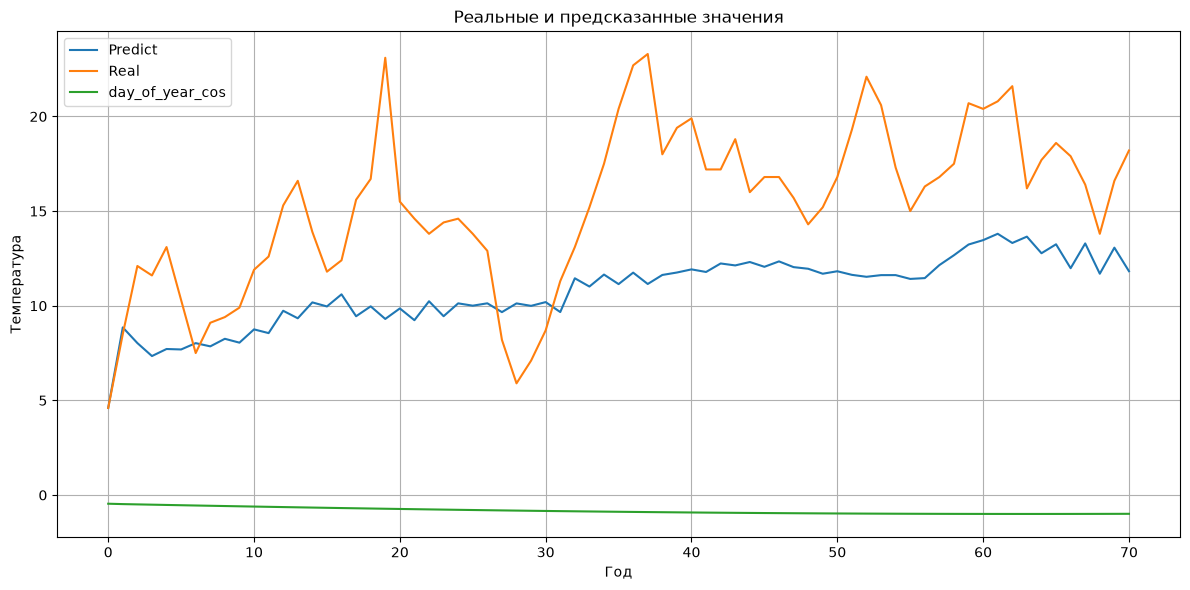

In [14]:
x_indexes = range(predict_day_num+1)
pred_vals = df_new['sr_temp']

positions = np.where(mask)[0]
if len(positions) == 0:
    raise ValueError("Строка с заданной датой не найдена")
pos = positions[0]
incl_30 = df.iloc[pos : pos+1+predict_day_num]

plt.figure(figsize=(12, 6))
plt.plot(x_indexes, pred_vals, label='Predict')
plt.plot(x_indexes, incl_30['sr_temp'], label='Real')
plt.plot(x_indexes, df_new[name_max][-len(pred_vals):], label=name_max)
plt.xlabel('Год')
plt.ylabel('Температура')
plt.title('Реальные и предсказанные значения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()